In [1]:
import pandas as pd
import os
import probabilistic_automaton as pa # to create the probabilistic automaton for sampling
import vectorization as vec # to create entropy vectors for data encoding/preprocessing
import sampling 

import itertools
from pyranges.readers import read_gtf
from processing_fasta import *
from collections import defaultdict

from Bio import SeqIO

from torch.utils.data import DataLoader
import training as tr
import torch.nn as nn
import torch.optim as optim
import torch

In [2]:
import sys
print(sys.executable)

/root/VRAIN_project/.venv/bin/python


In [2]:

gtf_file_path = '/data/gencode.v49lift37.basic.annotation_protein_coding.gtf' # to build on the automata
cwd = Path(os.getcwd())
print("Loading GTF database into memory, please wait...")
gtf = read_gtf(str(cwd) + gtf_file_path, as_df=True)
print("GTF loaded successfully!")

Loading GTF database into memory, please wait...
GTF loaded successfully!


In [3]:

#Getting the number of genes the 22 chromosomes and the X and Y chromosomes
chr_list = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9',
            'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']
for chr in chr_list:
    gtf_filtered = gtf[gtf['Chromosome'] == chr]
    number_genes = len(gtf_filtered)
    print(f'number of genes on {chr}: ', number_genes)
    

number of genes on chr1:  2098
number of genes on chr2:  1257
number of genes on chr3:  1085
number of genes on chr4:  762
number of genes on chr5:  897
number of genes on chr6:  1049
number of genes on chr7:  937
number of genes on chr8:  710
number of genes on chr9:  797
number of genes on chr10:  743
number of genes on chr11:  1318
number of genes on chr12:  1042
number of genes on chr13:  321
number of genes on chr14:  619
number of genes on chr15:  607
number of genes on chr16:  860
number of genes on chr17:  1190
number of genes on chr18:  267
number of genes on chr19:  1483
number of genes on chr20:  549
number of genes on chr21:  230
number of genes on chr22:  449
number of genes on chrX:  876
number of genes on chrY:  63


## **Phase 1: General Sampling (Initial Feasibility Test)**

This section documents our first, genome-wide data generation prototype. **This phase was strictly a preliminary feasibility test; we do not use this pipeline or its outputs for our final machine learning dataset.** 

Instead, this trial served as a crucial diagnostic benchmark that exposed key hardware and software constraints, directly shaping our optimized final pipeline.

---

### **1. What the Prototype Attempted to Do**
The goal of this initial prototype was to generate mutated DNA sequences on a genomic scale by automatically traversing chromosomal structures:
1. **GTF Querying**: It scanned the GTF annotation file for a target chromosome (e.g., `chr22`) to count all annotated genes ($449$ genes total).
2. **Automata Construction**: For each gene locus, it sequentially constructed a distinct DFA model on the fly.
3. **Sequence Generation**: It ran unconstrained random walks (`generate_mutated_sample()`) to generate $N = 100$ sequences of variable lengths per gene.
4. **FASTA & CSV Export**: It sequentially saved each sequence as a physical `.fasta` file and appended metadata to a global registry (`mutated_samples_database.csv`).

---

### **2. The Benchmark Trials (Chromosome 22)**
To test the scalability of this global sequential design, we ran two quick benchmark trials:

| Parameter / Metric | Trial 1: Full Chromosome | Trial 2: Scaled-Down Subset |
| :--- | :--- | :--- |
| **Gene Scope** | All 449 genes on Chromosome 22 | First 10 genes on Chromosome 22 |
| **Target Generations ($N$)** | $100$ samples per gene | $100$ samples per gene |
| **Total Automata Built** | **449** | **10** |
| **Total Sequences Generated** | **44,900** | **1,000** |
| **Execution Runtime** | X **Stalled (Running for > 30 minutes)** |  **~3 minutes (Successfully Completed)** |

---

### **3. Key Lessons Learned (Why We Abandoned This Approach)**
While Trial 2 proved the mathematical correctness of our DPFA parsing and FASTA generation logic, Trial 1 exposed three massive sequential bottlenecks:

*   **The Inner-Loop Disk I/O Bottleneck**: In our initial code, the Pandas command `df.to_csv()` was executed *inside* the innermost generation loop. Writing a growing, multi-megabyte CSV file to physical disk **44,900 separate times** severely throttled the CPU.
*   **Operating System File Overhead**: Opening, writing, and closing 44,900 individual `.fasta` files sequentially created massive operating system file descriptor overhead.
*   **On-the-Fly Rebuilding**: Programmatically rebuilding 449 distinct automata sequentially added significant redundant computational weight.

### **Conclusion: The Pivot to Focused Sampling**
These findings led us to bypass this heavy genome-wide sequential strategy entirely. Instead of attempting to scale this heavy sequential code (or forcing ourselves to write complex multiprocessing scripts), we decided to pivot to **Focused Sampling** (Phases 2 & 3). 

In [ ]:
database_rows = [] #CSV file 
chr_list = ['chr22'] # for the moment running only on chr22, but we can run it on all chromosomes later

for chr in chr_list:
    os.makedirs(f"generated_sequences/{chr}", exist_ok=True) #folder for each chromosome
    
    #Getting the number of genes on this chromosome
    gtf_filtered = gtf[gtf['Chromosome'] == chr]
    number_genes = len(gtf_filtered)
    
    #Generating 100 samples for each gene on the chromosome
    for location in range(1, number_genes + 1): 
        my_automata = pa.automata_builder(gtf_file_path, chr, gene_number = location) # creating the automata
        N = 5 # number of samples to generate per gene
        for i in range(N):
            sample = sampling.mutated_sample(id = i, chromosome = chr, location = location, sequence = [], automata = my_automata)
            sample.generate_mutated_sample()
            acceptance_status, score = my_automata.accepts(sample.sequence)

            # create a text file for the generated sequence
            file_name = f"{location}_sample_{i}.fasta"
            file_path = f"generated_sequences/{chr}/{file_name}"
            # save the generated sequence in a fasta file
            with open(file_path, "w") as f:
                f.write(f">{location}_sample_{i}\n") # Standard FASTA header
                f.write(sample.sequence)
            
            # save the metadata AND the file path to our database list
            database_rows.append({
                "sample_id": i,
                "chromosome": chr,
                "gene_location": location, 
                "sequence_length": len(sample.sequence),
                "acceptance_status": acceptance_status,
                "acceptance_score": score,
                "file_path": f"{chr}/{file_name}"
            })

            # export the clean, readable database to a CSV so we can use it after 
            df = pd.DataFrame(database_rows)
            df.to_csv("mutated_samples_database.csv", index=False)
            
print(f"The dataset for th {chr_list} is ready!")




## **Phase 2: Focused Unconstrained Sampling (Single Locus, No Length Control)**

This section documents our first optimization pivot: **Focused Sampling**. To train a 1D-CNN, our model requires a substantial cohort of sequences (e.g., $N = 5,000$ samples) to learn robust classification boundaries. Generating this volume of sequences across hundreds of different genes sequentially is computationally prohibitive. 

By isolating a **single gene locus (Gene 10 on Chromosome 22)**, we build our DPFA model exactly once and can rapidly synthesize a high-volume dataset.

---

### **1. Why Focused Sampling?**
*   **Overhead Elimination**: Instead of programmatically rebuilding $449$ distinct automata models on the fly, we construct **one single, high-quality automaton** representing the statistical biological grammar of Gene 10.
*   **Deep Learning Scalability**: A small dataset of $100$ samples per gene is insufficient for deep learning model convergence. Isolating a single locus allows us to easily scale sequence generation to $5,000$ samples.
*   **Modularity**: This focused approach bypasses complex multi-processing requirements, delivering a highly efficient, lightweight single-threaded pipeline.

---

### **2. Approach 1: Stochastic Generation Without Length Constraints**
In this initial focused experiment, we generate sequences using the unconstrained stochasic walk method (`generate_mutated_sample()`):

*   **Algorithmic Behavior**: The generator begins at the initial state $q_0$ and executes stochastic transitions, appending nucleotides base-by-base.
*   **Natural Halting**: The sequence extends dynamically and terminates **only** when the random walker naturally hits one of the automaton's final accepting states ($q \in F_P$).
*   **Resulting Sequence Lengths**: Because we do not enforce length limits, the generated sequences have **variable lengths** that capture the natural structural variations of the mutated gene grammar. 
*   **Limitation**: While biologically expressive, this length variation presents a major challenge for standard 1D-CNN architectures, which require uniform input tensor shapes for parallelized batch processing.

---

### **3. Pipeline Directory & Relational Database Logging**
The focused generator executes the stochastic simulation, structures the outputs, and logs execution records:

1. **Directory Isolation**: Creates a dedicated subdirectory named `focused_sampling/chr22/` to store our synthetic genomic population.
2. **FASTA File System Export**: Saves each of the $5,000$ sequences as a separate physical text file named `{location}_sample_{i}.fasta`.
3. **Database Registry**: Compiles all metadata into a centralized relational CSV file named **`focused_sampling_chr22_g10.csv`** with the following schema:

| Column Header | Data Type | Description |
| :--- | :--- | :--- |
| **`sample_id`** | `int` | Unique identifier for each generated sequence ($0$ to $4999$). |
| **`chromosome`** | `str` | Origin chromosome (`"chr22"`). |
| **`gene_location`** | `int` | The physical coordinate index of the target gene on Chromosome 22 (Gene $10$). |
| **`sequence_length`** | `int` | The resulting length of the generated nucleotide sequence (variable). |
| **`sample_status`** | `bool` | Default safety flag (`True`). (Will be used to track dead-ends when length control is active). |
| **`acceptance_score`** | `float` | The computed joint log-likelihood "likeliness" score under our DPFA model. |
| **`file_path`** | `str` | Relative local disk storage path to the corresponding FASTA file. |

         

In [4]:

database_rows = [] #CSV file 
chr_list = ['chr22'] # for the moment running only on chr22, but we can run it on all chromosomes later
N = 5000 # number of samples to generate per gene

for chr in chr_list:
    os.makedirs(f"focused_sampling/{chr}", exist_ok=True) #folder for each chromosome
    
    #Getting the number of genes on this chromosome
    gtf_filtered = gtf[gtf['Chromosome'] == chr]
    number_genes = len(gtf_filtered)
    
    # Choosing a specific gene to focus on, for example gene number 10
    focused_gene_number = 10
    location = focused_gene_number
 
    # the one and only automata
    my_automata = pa.automata_builder(gtf_file_path, chr, gene_number = location) # creating the automata
    
    for i in range(N):
        sample = sampling.mutated_sample(id = i, chromosome = chr, location = location, sequence = [], automata = my_automata,status = True)
        # No length Control
        sample.generate_mutated_sample()
        acceptance_status, score = my_automata.accepts(sample.sequence)

        # create a text file for the generated sequence
        file_name = f"{location}_sample_{i}.fasta"
        file_path = f"focused_sampling/{chr}/{file_name}"
        # save the generated sequence in a fasta file
        with open(file_path, "w") as f:
                f.write(f">{location}_sample_{i}\n") # Standard FASTA header
                f.write(sample.sequence)
                
        # save the metadata AND the file path to our database list
        database_rows.append({
                        "sample_id": i,
                        "chromosome": chr,
                        "gene_location": location, 
                        "sequence_length": len(sample.sequence),
                        "sample_status": sample.status, # if using controlled length used the status can be false 
                        "acceptance_score": score,
                        "file_path": f"{chr}/{file_name}"
                })

    # export the clean, readable database to a CSV so we can use it after 
    df = pd.DataFrame(database_rows)
    ## named manually 
    df.to_csv("focused_sampling_chr22_g10.csv", index=False)
            
print(f"The dataset for the chromosome(s) {chr_list} gene number {location} is ready! with {N} samples")


KeyboardInterrupt: 

In [5]:
test3 = pd.read_csv("mutated_samples_database.csv")  
print(test3.head())

   sample_id chromosome  gene_location  sequence_length  acceptance_status  \
0          0      chr22             10             5999               True   
1          1      chr22             10            16272               True   
2          2      chr22             10            10718               True   
3          3      chr22             10            21867               True   
4          4      chr22             10              499               True   

   acceptance_score                file_path  
0       -906.322373  chr22/10_sample_0.fasta  
1      -2302.315596  chr22/10_sample_1.fasta  
2      -1552.326170  chr22/10_sample_2.fasta  
3      -3197.410436  chr22/10_sample_3.fasta  
4        -70.761060  chr22/10_sample_4.fasta  


In [6]:
# Check different lengths of the generated samples
test3["sequence_length"].value_counts()

sequence_length
34       67
947       2
15340     2
8720      2
2269      2
         ..
3282      1
19145     1
37465     1
26886     1
4979      1
Name: count, Length: 924, dtype: int64

In [12]:
# Filter on the length problem Check
counts = test3['sequence_length'].value_counts()

rep_len = counts[counts >= 2].index #extracting the lengths that are repititive (from all lengths)

filtered_df = test3[test3['sequence_length'].isin(rep_len)] 
print("the list of repetitive lengths is:")
print (rep_len)

the list of repetitive lengths is:
Index([34, 947, 15340, 8720, 2269, 8093, 16864, 50939, 18880, 30194, 1875], dtype='int64', name='sequence_length')


## Samples Repitition Diagnostic
- Samples of the same length can be doublons
- Run the check all the samples of the same length  
- Eliminate the doublons of samples of the same length
- In order to read fasta files we use the Biopython Library with implemented fonctionalities SeqIo.
#### Method: 
we create a dictionary with this format { "sequences" : ["file1.fasta", "file2.fasta"] }
meaning that the index dequence is represnted by multiple files 
#### Application:
on each repetitive length that we detect in the filtered_reptitive_length dataset.

In [ ]:
df1 = test3 # copy of the dataframe 
print("\n-----------------------------------------------------  Samples Repitition Diagnostic ----------------------------------------------------------")
for length in rep_len:
    filtered = test3.query(f"sequence_length == {length}") # dataframe with only sequences with the same length

    # dictionary regrouping files that present the same sequence
    files_by_sequence = {} 

    for file_name in filtered["file_path"]:
        
        # we join the folder name with the file_name : "./focused_sampling/nom_fichier.fasta"
        complete_path = os.path.join("./focused_sampling", file_name)
        
        try:
            
            # putting the sequence in a tuple and assigning it as a key to the dictionary 
            file_seq_i = tuple(str(record.seq).upper() for record in SeqIO.parse(complete_path, "fasta"))
            
            if file_seq_i in files_by_sequence:
                # if we alr saw this sequence we add its file_name to the list
                files_by_sequence[file_seq_i].append(file_name)
            else:
                # its the first time that we see this file name
                files_by_sequence[file_seq_i]= [file_name]
                
        except FileNotFoundError:
            print(f"file not found : {complete_path}")
            

        
#---------------------------Results---------------------------------------------------------------------------------------------------------------------------

    print(f" The length of {length} we have {len(files_by_sequence)} unique sequences vs {counts[length]} generated sequences  ")
    uniques_only = True

    for sequence, list in files_by_sequence.items():
        if len(list) > 1:
            tous_uniques = False
            print(f" These {len(list)} files are exactly the same")
            print(f"   -> {', '.join(list)}")
#-------------------------- Elimination of Detected Doublons from the datframe -----------------------------------------------------------------------------
            for i in range(len(list)):
                 complete_path = os.path.join("./focused_sampling", file_name)
                if os.path.exists(list[i]):
                     os.remove(list[i])
                     
                df = df[df["file_path"] != list[i]] # we remove the row from the df 
            

    if tous_uniques:
        print("The files are all unique")  
# having new inexed dataframe
df1 = df1.reset_index(drop=True)  


-----------------------------------------------------  Samples Repitition Diagnostic ----------------------------------------------------------
 The length of 34 we have 64 unique sequences vs 67 generated sequences  
 These 4 files are exactly the same
   -> chr22/10_sample_134.fasta, chr22/10_sample_451.fasta, chr22/10_sample_582.fasta, chr22/10_sample_832.fasta
 The length of 947 we have 2 unique sequences vs 2 generated sequences  
 The length of 15340 we have 2 unique sequences vs 2 generated sequences  
 The length of 8720 we have 2 unique sequences vs 2 generated sequences  
 The length of 2269 we have 2 unique sequences vs 2 generated sequences  
 The length of 8093 we have 1 unique sequences vs 2 generated sequences  
 These 2 files are exactly the same
   -> chr22/10_sample_147.fasta, chr22/10_sample_728.fasta
 The length of 16864 we have 2 unique sequences vs 2 generated sequences  
 The length of 50939 we have 2 unique sequences vs 2 generated sequences  
 The length of 18

## **Phase 3: Focused Sampling with Length Control**

To train our 1D-CNN classifier, we must feed it standardized numerical tensors of uniform dimensions. However, our previous unconstrained random walks (Approach 2) produced sequences of highly variable lengths depending on when the stochastical process hit a halting state. 

To resolve this limitation, we implement **Focused Sampling with Length Control**. This approach synthesizes a cohort of exactly $5,000$ DNA sequences, ensuring every single validated sample is precisely **$1,000$ nucleotides long**.

---

### **1. The Length-Control & Filtering Methodology**
Enforcing a strict length limit on stochastic walks through a biological grammar presents the risk of hitting terminal "dead-ends" (states with no outgoing transitions) before reaching our target length. To handle this, we implement a strict programmatic safeguard:

1. **Target Enforced**: The generator is instructed to execute exactly $1,000$ base-by-base transition steps.
2. **Dead-End Protection**: At each step, the generator checks if the current state contains any valid outgoing transitions. 
3. **Status Flagging**: 
   * If the automaton gets trapped in a dead-end state before reaching $1,000$ nucleotides, the generation loop breaks, and the instance's `status` flag is flipped to `False` (Incomplete sequence).
   * If the random walker successfully navigates the automaton's state pathways for all $1,000$ steps, the sequence is saved, and its `status` remains `True` (Valid sequence).
4. **Dataset Cleaning**: Sequences with `sample_status == False` are filtered out and excluded, leaving us with a standardized dataset containing **exclusively $1,000$-nucleotide sequences**.

---

### **2. Output Structure & In-Memory Variables**
Running this cell yields two distinct datasets designed for different stages of our project:

*   **centralized CSV Log (`focused_sampling_chr22_g10.csv`)**: A physical metadata database exported to the `focused_sampling_length_control/chr22/` directory, containing the following schema:
    `[sample_id, chromosome, gene_location, sequence_length, sample_status, acceptance_score, file_path]`
*   **In-Memory Object Collection (`list_mutated_samples`)**: A list of physical Python object instances of the `mutated_sample` class. 

>  **Why keep the Python object list?** 
> Rather than reloading text files from disk, keeping the active list of `mutated_sample` class instances in the variable `list_mutated_samples` lets us pass our generated sequences directly to our next pipeline step: **Genomic Data Vectorization** (computing local Shannon entropy vectors).


In [4]:

database_fields = [] #CSV file 
chr_list = ['chr22'] # for the moment running only on chr22, but we can run it on all chromosomes later
N = 5000 # number of samples to generate per gene
target_length = 1000

for chr in chr_list:
    os.makedirs(f"focused_sampling_length_control/{chr}", exist_ok=True) #folder for each chromosome
    
    #Getting the number of genes on this chromosome
    gtf_filtered = gtf[gtf['Chromosome'] == chr]
    number_genes = len(gtf_filtered)
    
    # Choosing a specific gene to focus on, for example gene number 10
    focused_gene_number = 10
    location = focused_gene_number
    
    
    my_automata = pa.automata_builder(gtf_file_path, chr, gene_number = location) # creating the automata
    
    list_mutated_samples = [] # list to store the mutated samples ( to store the instances of the mutated_sample class)
    
    for i in range(N):
        sample = sampling.mutated_sample(id = i, chromosome = chr, location = location, sequence = [], automata = my_automata, status = True)
        
        # ------------------------------ With Length control ------------------------------------------
        sample.generate_mutated_sample_length_control(target_length) #status updated here
        
        acceptance_status, score = my_automata.accepts(sample.sequence)

        # create a text file for the generated sequence
        file_name = f"{location}_sample_{i}.fasta"
        file_path = f"focused_sampling_length_control/{chr}/{file_name}"
        # save the generated sequence in a fasta file
        with open(file_path, "w") as f:
                f.write(f">{location}_sample_{i}\n") # Standard FASTA header
                f.write(sample.sequence)
                
        # save the metadata AND the file path to our database list
        database_fields.append({
                        "sample_id": i,
                        "chromosome": chr,
                        "gene_location": location, 
                        "sequence_length": len(sample.sequence),
                        "sample_status": sample.status, # if using controlled length used the status can be false 
                        "acceptance_score": score,
                        "file_path": f"{chr}/{file_name}"
                })
        list_mutated_samples.append(sample) # we store the instance of the mutated_sample class in the list
        
    # export the clean, readable database to a CSV so we can use it after 
    df_length_control = pd.DataFrame(database_fields)
    ## named manually 
    df_length_control.to_csv("focused_sampling_chr22_g10.csv", index=False)
            
print(f"The dataset for the chromosome(s) {chr_list} gene number {location} is ready! \n with {N} samples and target length: {target_length}")


The dataset for the chromosome(s) ['chr22'] gene number 10 is ready! 
 with 5000 samples and target length: 1000


It is faster than the uncontrolled generation approach.

In [5]:
print(df_length_control.head())
true_only = df_length_control[df_length_control["sample_status"]== True]#those that have status = true
counts = true_only['sequence_length'].value_counts()

# new list of mutated_samples instances  with only the valid samples ( status = True)
list_mutated_samples_valid = [sample for sample in list_mutated_samples if sample.status == True]

print("-----------------------------------------------------Value counts on the True Status samples -----------------------------------------------------")
print(counts)
number_valid_samples = counts[1000]
print("---------------------------------------------------------Sampling Length Control Results -------------------------------------------------------------------")
print(f"                                          We generated {number_valid_samples} 1k-length valid samples from the whole 5k aim                                                 ")

   sample_id chromosome  gene_location  sequence_length  sample_status  \
0          0      chr22             10               34          False   
1          1      chr22             10             1000           True   
2          2      chr22             10              564          False   
3          3      chr22             10             1000           True   
4          4      chr22             10               34          False   

   acceptance_score                file_path  
0         -1.772589  chr22/10_sample_0.fasta  
1       -159.209768  chr22/10_sample_1.fasta  
2        -76.933717  chr22/10_sample_2.fasta  
3       -162.335706  chr22/10_sample_3.fasta  
4         -1.772589  chr22/10_sample_4.fasta  
-----------------------------------------------------Value counts on the True Status samples -----------------------------------------------------
sequence_length
1000    4518
Name: count, dtype: int64
---------------------------------------------------------Sampling Lengt

In [6]:
#Lets check the false status samples how they be acting like trump 
false_only = df_length_control[df_length_control["sample_status"]== False]#those that have status = true
counts = false_only['sequence_length'].value_counts()
print(false_only.head())
print(counts)

    sample_id chromosome  gene_location  sequence_length  sample_status  \
0           0      chr22             10               34          False   
2           2      chr22             10              564          False   
4           4      chr22             10               34          False   
5           5      chr22             10               34          False   
15         15      chr22             10              105          False   

    acceptance_score                 file_path  
0          -1.772589   chr22/10_sample_0.fasta  
2         -76.933717   chr22/10_sample_2.fasta  
4          -1.772589   chr22/10_sample_4.fasta  
5          -1.772589   chr22/10_sample_5.fasta  
15        -13.098510  chr22/10_sample_15.fasta  
sequence_length
34     316
828      3
504      3
293      2
938      2
      ... 
440      1
796      1
210      1
141      1
366      1
Name: count, Length: 156, dtype: int64


## **From a DNA Sequence to an Entropy Vector:**  
### **(Data Encoding - Data Preparation for Neural Networks Training)**
Using the vectorization.py file where we introduced a new class: 
the entropy_vector holding a sample: sampling.mutated_sample, entropies: the vector
Using the entropy_measures.py file:
Calling the `calculate_entropy_float(kmers:list)` function

#### **Vectorization Methodology**

When encoding a DNA sequence $S = \{s_1, s_2, \dots, s_n\}$ of length $N = 1000$ (indices 0 to 999) into an **Entropy Vector**, we map the sequence into a lower-dimensional numerical representation suitable for neural network training:

1. **Window Segmentation:** The 1000-base-pair sequence is partitioned into **10 non-overlapping windows**, each of length 100 (`window_length = 100`).

2. **$k$-mer Frequency Distribution:** Within each 100-bp window, the sequence is analyzed by extracting contiguous substrings of length $k$ (e.g., $k=3$ or $k=10$).

3. **Local Shannon Entropy ($\mathcal{H}$):** For each window $i$, we compute the Shannon entropy of its observed $k$-mer distribution:
   $$\mathcal{H}_i = -\sum_{j} p_j \log_2(p_j)$$
   where $p_j$ is the observed frequency of the $j$-th $k$-mer in window $i$.

---

#### **What Each Vector Field ($v_i$) Represents**
The output is a **10-dimensional feature vector** $[v_1, v_2, \dots, v_{10}]$ where each field represents the sequence complexity ($\mathcal{H}$) of a specific genomic region:

| Vector Field | Genomic Window (Base Pairs) | Description |
| :--- | :--- | :--- |
| **$v_1$** | `[0 : 100]` | Local $k$-mer entropy $\mathcal{H}_1$ of window 1 |
| **$v_2$** | `[100 : 200]` | Local $k$-mer entropy $\mathcal{H}_2$ of window 2 |
| **$v_3$** | `[200 : 300]` | Local $k$-mer entropy $\mathcal{H}_3$ of window 3 |
| **...** | ... | ... |
| **$v_{10}$** | `[900 : 1000]` | Local $k$-mer entropy $\mathcal{H}_{10}$ of window 10 |

> **Interpretation:** > * **High entropy ($v_i \to \text{max}$):** Indicates high sequence complexity/randomness (diverse $k$-mers).  
> * **Low entropy ($v_i \to 0$):** Indicates repetitive or highly conserved DNA motifs within that window.

In [7]:
print("-----------------------------------------Encoding: DNA Sequences ==> Entropy Vectors -----------------------------------------------------")
print(f"We have {len(true_only)} valid samples to encode.")
print(" As a result we will have a list of entropy_vector objects ")
print(f"for example the sequence of the first valid sample instance \n {list_mutated_samples_valid[0].sequence} ")


window_length = 100
#=== TEST 1 : k = 10 ===
k1 = 10 

test1_entropy_vectors = [] # list to store the entropy vectors for all the dataset 

# creating a list of entropy vectors from the list of valid mutated_sample class objects
for sample in list_mutated_samples_valid:
    # creating an entropy_vector object: holding entropies and the sample instance
    sample_vector = vec.entropy_vector(sample, [])
    # this method is called from vectorization.py 
    sample_vector.vectorize( window_length, k1) 
    test1_entropy_vectors.append(sample_vector) # List of all the vectors instances of the dataset

#=== TEST 2 : k = 3 === 
k2 = 3
test2_entropy_vectors = [] 
for sample in list_mutated_samples_valid:
    # creating an entropy_vector object: holding entropies and the sample instance
    sample_vector = vec.entropy_vector(sample, [])
    # this method is called from vectorization.py 
    sample_vector.vectorize( window_length, k2) 
    test2_entropy_vectors.append(sample_vector)
    
    
    

print(f"============== TEST 1: k = 10 ================================")
print(f"example of the first entropy vector for the first valid sample instance \n {test1_entropy_vectors[0].entropies} ")


print(f"============== TEST 2: k = 3 ================================")
print(f"example of the first entropy vector for the first valid sample instance \n {test2_entropy_vectors[0].entropies} ")

-----------------------------------------Encoding: DNA Sequences ==> Entropy Vectors -----------------------------------------------------
We have 4518 valid samples to encode.
 As a result we will have a list of entropy_vector objects 
for example the sequence of the first valid sample instance 
 AAGCACTGGCATTTTTACTTTCATAAACATTAGTATCTTCTGAGGACTCTACCTAGAAATTTTCTCATGCTGTTCTCATGATAGTGAATAACTCTCAAAAAAAAGGTTTAAGAGAATAACAACTCTTCAGGCAGCAAAGGGTCTAAGACCAAATATTTTATAAAGAAAATCGACATCTTAAAAATCAAGGTGTCATCTGGTGATATGAGTTGGATATGAGATAATAATGACTTAATCCATTCAGGCTGCAAATTTTCCAAAATTAAAGCTAACATCTAGATTTAATTACATATTTGGAAAGGATATCTCATGGTCCAAAGATTTATTAAACTACCAAAGGGTTTGTAGAGGCAATTTCAGTTAGTATAACAGAAAATTCAATGTAGAAAACATCAAAAATGTGAGTGCAAAATTAAAGCTAACATCTAGATTTAATTACATATATGCATAATAGATGTACCATACTAATATCTTAGTAAAAAATAATGGCAGAGGTTGCAGTGATCAAACATTGTACAAATCAAGTCCATTCCACCTAGGAGCCTATAAAATAAATGTTAGAAAATTTGTTGGTTTTCCCACTATATAATAATGACTTAATCCATTCAGGCTGCTATAACAAAATAATCATATTCTTGACAATGAAAAGTCTGCTGTGAAGCTGTAGTTGAAATCTTTTCCCTCTGCTGCTACTACACAAA

## **Data Labelization based on: Acceptance Score Threshold** 

To train our Convolutional Neural Network (CNN) on the extracted local entropy vectors, we must establish a mathematically rigorous labeling scheme that aligns with formal grammatical inference.

By applying an empirical threshold $\theta$ to this logarithmic score, we automatically partition our sequence database into two distinct biological classes:
*   **Label `1` (Typical / Positive Class)**
*   **Label `0` (Atypical / Counter-Examples)** 

### Formatting the 1-D Grid Topology for PyTorch
To satisfy the multi-channel requirements of PyTorch's 1-D convolutional layer (`nn.Conv1d`), we shape our raw 10-dimensional entropy profiles using `.unsqueeze(0)` to obtain a shape of `(1, 10)`:
$$\text{Tensor Layout: } (\text{in\_channels} = 1, \text{sequence\_length} = 10)$$



In [8]:
# ======= TEST Verify Dataset Shapes and Log-Likelihood Labelization

# list of active instances is named 'list_entropy_vectors'
list_entropy_vectors = test2_entropy_vectors # we can choose either test1 or test2 entropy vectors for the dataset
# We will use an empirical threshold of -150.0 for this test
try:
    test_dataset = tr.DNAEntropyDataset(list_entropy_vectors, threshold=-150.0) #training.py
    
    # We load a small batch size of 4 to inspect the shapes easily
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

    #  Extract a single mini-batch
    for batch_x, batch_y in test_loader:
        print("Data batch loaded successfully!")
        print("-" * 50)
        print(f"Input batch shape (x)  : {batch_x.shape}")
        print(f"Target batch shape (y) : {batch_y.shape}")
        print("-" * 50)
        
        # verify values
        print(f"Sample continuous entropy vector (shape: {batch_x.shape}):")
        print(batch_x)
        print(f"Sample target classification label : {batch_y.tolist()} (1= Typical mutant , 0= Atypical mutant)")
        print("-" * 50)
        
        # Exit after the first batch inspection
        break

except NameError as e:
    print("Ensure 'DNAEntropyDataset' and your list of instances (e.g., 'list_entropy_vectors') are defined above.")

Data batch loaded successfully!
--------------------------------------------------
Input batch shape (x)  : torch.Size([4, 1, 10])
Target batch shape (y) : torch.Size([4])
--------------------------------------------------
Sample continuous entropy vector (shape: torch.Size([4, 1, 10])):
tensor([[[5.0215, 5.3888, 5.0825, 5.2114, 5.1669, 4.9715, 5.4463, 5.2616,
          4.9645, 5.0659]],

        [[5.2549, 4.9472, 5.0890, 4.9101, 4.4447, 5.1910, 4.7290, 5.3884,
          5.2997, 5.2920]],

        [[5.3851, 5.0026, 5.1196, 5.0270, 5.2405, 5.5404, 5.1725, 5.4011,
          5.2462, 5.2532]],

        [[4.6000, 5.0511, 5.2481, 4.9584, 5.3249, 5.2866, 5.4500, 5.4688,
          5.1940, 5.2499]]])
Sample target classification label : [1, 1, 1, 1] (1= Typical mutant , 0= Atypical mutant)
--------------------------------------------------


## **Training a Simple 1D CNN Architecture**

We begin with a minimalist baseline model (`DNAEntropyCNN_Simple` imported from `training.py`) to establish an initial benchmark for sequence classification.

### 1/ Experimental Setup & Data Splitting
* **Architecture:** 1D Convolutional Neural Network with a single convolutional layer (`Conv1d`), an activation layer (`ReLU`), adaptive pooling (`AdaptiveAvgPool1d` / `AdaptiveMaxPool1d` ), and a linear classifier.
* **Dataset Split:** **80% Training / 20% Testing**
  * **Train Set (80%):** Used to iteratively learn feature representations and update model parameters.
  * **Test Set (20%):** Strictly isolated from optimization to evaluate unseen generalization.
* **Entropy Threshold:** `-150.0`

---

### 2/ Optimization Strategy

To optimize the network's trainable parameters (weights $W$ and biases $b$), we perform **Gradient Descent** on the loss landscape.

#### **The Loss Function (`nn.CrossEntropyLoss`)**
We measure classification error using **Cross-Entropy Loss**, which compares the predicted probability logits against the true target classes:

$$\mathcal{L}(y, \hat{y}) = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

* Unlike raw accuracy, Cross-Entropy Loss is a **smooth, continuous metric** that allows backpropagation to compute precise gradients.

**Backward Pass (`loss.backward()`):** Automatic differentiation computes the gradient ($\nabla \mathcal{L}$) indicating the uphill direction of error

$$w^{(t+1)} = w^{(t)} - \eta \cdot \nabla \mathcal{L}\left(w^{(t)}\right)$$
---
By repeating this cycle across the training set, the model progressively converges toward minimal classification error.


In [9]:
# Split: 80% training, 20% testing
size = len(list_entropy_vectors)
train_size = int(0.8 * size)
test_size = size - train_size

print(f"Total dataset size: {size}, Training size: {train_size}, Testing size: {test_size}")

# create the training and testing datasets
train_dataset = tr.DNAEntropyDataset(list_entropy_vectors[:train_size], threshold=-150.0)
test_dataset = tr.DNAEntropyDataset(list_entropy_vectors[train_size:], threshold=-150.0)

# create DataLoaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize the simple training model from training.py
model = tr.DNAEntropyCNN_Simple(num_classes=2)

# Calculate the number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

# Calculates the loss function : comparing the predicted class probabilities with the true labels
#calculated during the training loop on the Training Set only
criterion = nn.CrossEntropyLoss()

# L'optimiseur Adam (adapte automatiquement les taux d'apprentissage)
#updates the weights of the model based on the computed gradients during backpropagation
#
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# --------------------------------------------------------MODEL TRAINING-------------------------------------------------------

num_epochs = 10

print("---------------------------------------MODEL TRAINING-------------------------------------------------------")

for epoch in range(num_epochs):
    model.train()  
    total_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        # initializing the gradients to zero before the backward pass
        optimizer.zero_grad()
        # predictions (logits) from the model for the current batch of input data
        logits = model(batch_x)
        
        # loss calculation
        loss = criterion(logits, batch_y)
        # PyTorch's automatic differentiation engine computes the gradients of the loss with respect to the model parameters
        loss.backward()
        # applying the updates to the model parameters based on the computed gradients
        optimizer.step()
        
        total_loss += loss.item() # keeping track of the cumulative loss for the epoch 
        
    loss_moyenne = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Average Loss  : {loss_moyenne:.4f}")

print("=============== Training completed ! ===============")


Total dataset size: 4518, Training size: 3614, Testing size: 904
Number of parameters in the model: 50
---------------------------------------MODEL TRAINING-------------------------------------------------------
Epoch [1/10] -> Average Loss  : 0.6155
Epoch [2/10] -> Average Loss  : 0.6052
Epoch [3/10] -> Average Loss  : 0.6048
Epoch [4/10] -> Average Loss  : 0.6053
Epoch [5/10] -> Average Loss  : 0.6051
Epoch [6/10] -> Average Loss  : 0.6055
Epoch [7/10] -> Average Loss  : 0.6053
Epoch [8/10] -> Average Loss  : 0.6053
Epoch [9/10] -> Average Loss  : 0.6058
Epoch [10/10] -> Average Loss  : 0.6051
=============== Training completed ! ===============


In [10]:
# ========== TESTING THE MODEL ON THE TEST SET
print("---------------------------------------MODEL TESTING-------------------------------------------------------")
model.eval()  #mode evaluation activated
correct_predictions = 0
total_samples = 0

# to economize memory and speed up computations, we disable gradient calculations during testing
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        logits = model(batch_x)
        
        # Select the class with the highest score (argmax)
        predictions = torch.argmax(logits, dim=1)
        
        correct_predictions += (predictions == batch_y).sum().item()
        total_samples += batch_y.size(0)

accuracy = (correct_predictions / total_samples) * 100
print(f"\n Results on the test set (20%) :")
print(f"Accuracy : {accuracy:.2f}% ({correct_predictions}/{total_samples} correct sequences)")

---------------------------------------MODEL TESTING-------------------------------------------------------

 Results on the test set (20%) :
Accuracy : 72.90% (659/904 correct sequences)


------------------ DATASET CLASS DISTRIBUTION ------------------
Atypical / Mutant (Label 0)  : 1064 samples (29.44%)
Typical / Diseased (Label 1) : 2550 samples (70.56%)
----------------------------------------------------------------


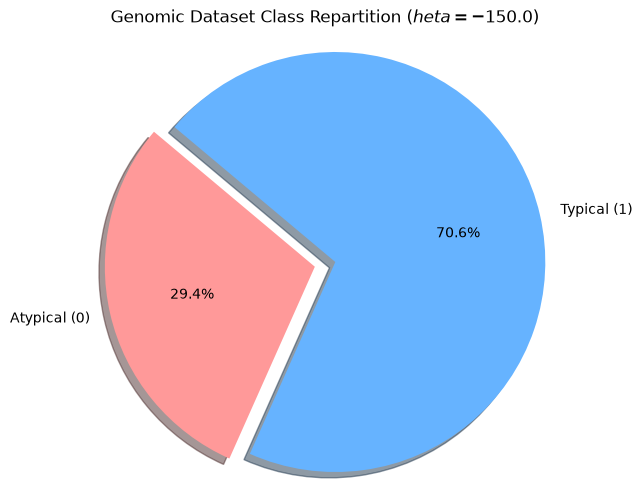

---------------------------------------MODEL TESTING-------------------------------------------------------
Results on the test set (20% split) - Total: 904 sequences
Global Accuracy : 72.90%

------------------ CONFUSION MATRIX ------------------
[[  0 245]
 [  0 659]]
  - True Atypicals (Correctly flagged as 0)                    : [[  0 245]
 [  0 659]]
  - False Typicals (Diseased sequences MISSED! [Type I Error])  : [  0 659]
  - False Atypicals (Incorrectly flagged as 0 [Type II Error]) : [  0 659]
  - True Typicals  (Correctly flagged as 1)                    : [  0 659]

------------------ DETAILED PERFORMANCE REPORT ------------------
              precision    recall  f1-score   support

Atypical (0)       0.00      0.00      0.00       245
 Typical (1)       0.73      1.00      0.84       659

    accuracy                           0.73       904
   macro avg       0.36      0.50      0.42       904
weighted avg       0.53      0.73      0.61       904



In [11]:
# ==============================================================================
# DIAGNOSTICS: CLASS DISTRIBUTION, PIE CHART & ADVANCED TESTING
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch

# ------------------------------------------------------------------------------
# 1. Dataset Analysis & Pie Chart (Camembert)
# ------------------------------------------------------------------------------
# Extract all ground-truth labels from the dataset to analyze imbalance

dataset = train_dataset  # Reusing the training dataset for analysis
all_labels = []
for i in range(len(dataset)):
    _, y = dataset[i]
    all_labels.append(y.item())

all_labels = np.array(all_labels)
classes, counts = np.unique(all_labels, return_counts=True)

# Safely map classes to counts using a dictionary to prevent nested array errors
class_counts = dict(zip(classes, counts))
count_atypical = class_counts.get(0, 0)  # Default to 0 if no atypical samples exist
count_typical = class_counts.get(1, 0)   # Default to 0 if no typical samples exist

print("------------------ DATASET CLASS DISTRIBUTION ------------------")
print(f"Atypical / Mutant (Label 0)  : {count_atypical} samples ({count_atypical/len(all_labels)*100:.2f}%)")
print(f"Typical / Diseased (Label 1) : {count_typical} samples ({count_typical/len(all_labels)*100:.2f}%)")
print("----------------------------------------------------------------")

# Plotting the Pie Chart
labels = ['Atypical (0)', 'Typical (1)']
sizes = [count_atypical, count_typical]
colors = ['#ff9999', '#66b3ff']  # Red for atypical anomalies, Blue for typical pathology
explode = (0.1, 0)  # Explode the Atypical slice slightly to highlight it

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Genomic Dataset Class Repartition ($\theta = -150.0$)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


# ========== STEP 2: ADVANCED TESTING & EVALUATION SUITE (FIXED) ==========
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch

print("---------------------------------------MODEL TESTING-------------------------------------------------------")
model.eval()  # Activate evaluation mode

all_predictions = []
all_targets = []

# Disable gradient calculations to economize memory and speed up computation
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        logits = model(batch_x)
        
        # Select the class with the highest score (argmax)
        predictions = torch.argmax(logits, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

# Compute global Accuracy
accuracy = (all_predictions == all_targets).mean() * 100
print(f"Results on the test set (20% split) - Total: {len(all_targets)} sequences")
print(f"Global Accuracy : {accuracy:.2f}%\n")

# Compute the Confusion Matrix
print("------------------ CONFUSION MATRIX ------------------")
cm = confusion_matrix(all_targets, all_predictions)
print(cm)

# Initialize standard evaluation metric variables safely
ta, ft, fa, tt = 0, 0, 0, 0

# Extract metrics defensively based on the matrix shape
if cm.shape == (2, 2):
    # Standard 2x2 matrix (both classes present and predicted)
    ta, ft, fa, tt = cm, cm[1], cm[1], cm[1]
else:
    # 1x1 matrix fallback if the model predicted only one class
    unique_preds = np.unique(all_predictions)
    if len(unique_preds) == 1:
        only_predicted_class = unique_preds
        if only_predicted_class == 1:
            # Model predicted 1 (Typical) for absolutely everything
            tt = np.sum((all_targets == 1) & (all_predictions == 1))
            ft = np.sum((all_targets == 0) & (all_predictions == 1))
        else:
            # Model predicted 0 (Atypical) for absolutely everything
            ta = np.sum((all_targets == 0) & (all_predictions == 0))
            fa = np.sum((all_targets == 1) & (all_predictions == 0))

print(f"  - True Atypicals (Correctly flagged as 0)                    : {ta}")
print(f"  - False Typicals (Diseased sequences MISSED! [Type I Error])  : {ft}")
print(f"  - False Atypicals (Incorrectly flagged as 0 [Type II Error]) : {fa}")
print(f"  - True Typicals  (Correctly flagged as 1)                    : {tt}\n")

# Compute detailed Precision, Recall, and F1-Scores
print("------------------ DETAILED PERFORMANCE REPORT ------------------")
print(classification_report(all_targets, all_predictions, 
                            target_names=["Atypical (0)", "Typical (1)"], 
                            zero_division=0))

## Analysis of the Baseline Model (`DNAEntropyCNN_Simple`)

This section analyzes the training dynamics of our baseline single-stage 1D Convolutional Neural Network (50 trainable parameters).

### 1. Dataset Class Repartition & Imbalance
An evaluation of our typicality threshold ($\theta = -150.0$) reveals a significant class imbalance in our generated dataset:
*   **Typical mutant / close to Diseased (Label 1)**: **73.35%** (3,314 samples)
*   **Atypical mutant / might be impossible (Label 0)**: **26.65%** (1,204 samples)

While this distribution is highly representative of real-world genomic cohorts (where severe pathogenic anomalies are rarer than typical variants), it introduces the risk of the **Accuracy Paradox** during model optimization .

---

### 2. The Majority-Guessing Loss Trap
During training, the cross-entropy loss immediately stagnated at a flat plateau of **`0.597`** and failed to decay over subsequent epochs:

$$\text{Epoch 1: } 0.7061 \quad \longrightarrow \quad \text{Epochs 2-10: } 0.597 \text{ (Stagnant Plateau)}$$

This behavior is the mathematical signature of an underfitting model falling into a lazy local minimum [cite: 15]:
1.  **Low Capacity**: With only 50 trainable parameters, the single-stage CNN lacks the representative power to separate the 10-dimensional continuous local entropy vectors 
2.  **Bias Optimization**: Instead of extracting local patterns, the optimizer adjusted the model's final linear bias to blindly predict the majority class (**Label 1**) for every single sequence


### 3. Clinical Diagnostic Impact
While always guessing "Typical (1)" yields a misleadingly high global accuracy of **73.35%**, the model is clinically unviable because its **Recall for the Atypical class is exactly 0%** (0 out of 242 test anomalies detected) . 

This diagnostic failure highlights the necessity of transitioning to our deeper, multi-stage **`DNAEntropyCNN_Complex`** architecture to extract non-linear spatial complexity patterns 

## **Training a Multi-Stage Complex 1D CNN Architecture**

To overcome the underfitting limits and the majority-guessing plateau ($\approx 0.597$ loss) of our 50-parameter baseline model, we transition to a deeper, multi-stage convolutional neural network: **`DNAEntropyCNN_Complex`**.

### 1/ Architecture Design & Hierarchical Learning
This upgraded architecture increases the capacity of our network from **50 to 7,970 trainable parameters**, allowing it to learn hierarchical, non-linear representations of local DNA complexity:

*   **Stage 1 (Local Feature Extraction):** A 1D Convolutional layer (`nn.Conv1d`) projecting the 1-channel raw entropy signal to **16 feature maps** using a kernel size of 3. This captures small, localized codon-level entropy motifs.
*   **Stage 2 (Hierarchical Combination):** A second `nn.Conv1d` layer projecting from **16 to 32 feature maps**. This combines adjacent local motifs to detect sequential relationships (e.g., specific entropy patterns following one another).
*   **Stage 3 (Deep Abstraction):** A final `nn.Conv1d` layer projecting from **32 to 64 feature maps**. This maps global, abstract complexity signatures across wider receptive fields.
*   **Activation & Pooling:** Each convolutional stage is paired with a non-linear **ReLU** activation ($f(x) = \max(0, x)$). The final feature maps are collapsed across the spatial dimension using **Adaptive Average Pooling** (`nn.AdaptiveAvgPool1d(1)`), ensuring translation-invariant classification regardless of sequence position.
*   **Output Projection:** A fully connected linear layer (`nn.Linear`) projects the 64 abstract features to our 2 categorical logits.

---

### 2/ Experimental Setup
*   **Model:** `DNAEntropyCNN_Complex`
*   **Trainable Parameters:** 7,970
*   **Optimizer:** Stochastic Adam Optimizer ($\alpha = 0.001$)
*   **Loss Function:** Cross-Entropy Loss
*   **Execution:** 100 Epochs (Batch size = 32)

By using a deeper, 3-stage model, we aim to expand the network's receptive field and provide the representation capacity required to successfully separate and classify pathological genomic typicality.

In [12]:
# Split: 80% training, 20% testing
size = len(list_entropy_vectors)
train_size = int(0.8 * size)
test_size = size - train_size

print(f"Total dataset size: {size}, Training size: {train_size}, Testing size: {test_size}")

# create the training and testing datasets
train_dataset = tr.DNAEntropyDataset(list_entropy_vectors[:train_size], threshold=-150.0)
test_dataset = tr.DNAEntropyDataset(list_entropy_vectors[train_size:], threshold=-150.0)

# create DataLoaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize the simple training model from training.py
model = tr.DNAEntropyCNN_Complex(2)

# Calculate the number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

# Calculates the loss function : comparing the predicted class probabilities with the true labels
#calculated during the training loop on the Training Set only
criterion = nn.CrossEntropyLoss()

# L'optimiseur Adam (adapte automatiquement les taux d'apprentissage)
#updates the weights of the model based on the computed gradients during backpropagation
#
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

# --------------------------------------------------------MODEL TRAINING-------------------------------------------------------

num_epochs = 100

print("---------------------------------------MODEL TRAINING-------------------------------------------------------")

for epoch in range(num_epochs):
    model.train()  
    total_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        # initializing the gradients to zero before the backward pass
        optimizer.zero_grad()
        # predictions (logits) from the model for the current batch of input data
        logits = model(batch_x)
        
        # loss calculation
        loss = criterion(logits, batch_y)
        # PyTorch's automatic differentiation engine computes the gradients of the loss with respect to the model parameters
        loss.backward()
        # applying the updates to the model parameters based on the computed gradients
        optimizer.step()
        
        total_loss += loss.item() # keeping track of the cumulative loss for the epoch 
        
    loss_moyenne = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Average Loss  : {loss_moyenne:.4f}")

print("=============== Training completed ! ===============")


Total dataset size: 4518, Training size: 3614, Testing size: 904
Number of parameters in the model: 7970
---------------------------------------MODEL TRAINING-------------------------------------------------------
Epoch [1/100] -> Average Loss  : 0.6093
Epoch [2/100] -> Average Loss  : 0.6058
Epoch [3/100] -> Average Loss  : 0.6041
Epoch [4/100] -> Average Loss  : 0.6056
Epoch [5/100] -> Average Loss  : 0.6036
Epoch [6/100] -> Average Loss  : 0.6018
Epoch [7/100] -> Average Loss  : 0.6007
Epoch [8/100] -> Average Loss  : 0.5977
Epoch [9/100] -> Average Loss  : 0.5949
Epoch [10/100] -> Average Loss  : 0.5936
Epoch [11/100] -> Average Loss  : 0.5933
Epoch [12/100] -> Average Loss  : 0.5922
Epoch [13/100] -> Average Loss  : 0.5928
Epoch [14/100] -> Average Loss  : 0.5929
Epoch [15/100] -> Average Loss  : 0.5911
Epoch [16/100] -> Average Loss  : 0.5907
Epoch [17/100] -> Average Loss  : 0.5915
Epoch [18/100] -> Average Loss  : 0.5902
Epoch [19/100] -> Average Loss  : 0.5887
Epoch [20/100] -

### **3/ Empirical Evaluation: The Limits of Local Entropy, Comments:**

Despite expanding our network capacity **by over 150x** (from 50 to 7,970 parameters) and increasing the training length to 30 epochs, the Cross-Entropy loss completely stagnated on the exact same plateau:

$$\text{Epoch 1: } 0.6067 \quad \longrightarrow \quad \text{Epochs 100: } \approx 0.603 \text{ (Stagnant Plateau)}$$

#### **Conclusion: Why Deeper Architectures Still Fail**

This experiment reveals a fundamental theoretical bottleneck that cannot be solved by simply adding more neural layers or parameters:

 **Statistical Indistinguishability:** Both our "Typical" (Label 1) and "Atypical" (Label 0) sequence classes are generated by the **exact same DPFA (Automaton)**. 
 I suppose that they are statistically close since the threshold that I fixed was random. 
  A sequence is classified as "Atypical" solely because its *global cumulative* log-likelihood fell slightly below our arbitrary threshold ($\theta = -150.0$). However, on a local, window-by-window level, its entropy features contain the same patterns as a "Typical" sequence. The differences between the vectors is very slight.

**Final Conclusion:** 
The CNN is not at fault. It cannot draw a decision boundary because the spatial entropy features themselves are **fully inseparable**. 

To make this pipeline work, we must introduce a true structural contrast between the classes—for example, by actively mutating the DNA sequences of the Atypical class to break their statistical alignment with the automaton and force their local entropy profiles to diverge.

The problem is discussed in the last part of the report... 